# 音频零基础 4/6：采样、量化、PCM、位深与通道

这节课从生活中的声音出发，再落到 Python 数组。**先建立直觉，再看公式，最后用代码验证。**

| 项目 | 内容 |
|---|---|
| 本课要回答的问题 | 连续变化的声音怎样变成 WAV 文件中的整数或浮点数组？ |
| 前置要求 | 会运行 Notebook；看不懂代码时先读 Python/PyTorch 基础 1～3 |
| 建议投入 | 90～120 分钟，分成“直觉”和“代码”两次完成也可以 |
| 四个关键词 | 采样率、量化、位深、通道 |
| 通关证据 | 能用自己的话解释、能算一个数字例子、能画图验证、能从空白实现核心函数 |

本课不是词汇表。每出现一个量，都要写清楚：**它描述什么、单位是什么、数组中怎样表示、改变后听觉或图形怎样变化。**


## 课前回忆：先写猜测，不查答案

1. 对问题“连续变化的声音怎样变成 WAV 文件中的整数或浮点数组？”写下你现在的答案；不会就写“不知道”。
2. 四个关键词中，圈出最陌生的一个：采样率 / 量化 / 位深 / 通道。
3. 画一条横轴是时间的线，标出 0 秒、0.5 秒和 1 秒。
4. 写下一个可验证的预测：如果把声音的某个参数加倍，图或听感会怎样？

学完后回到这里，用另一种颜色修正。保留错误猜测，它是学习证据。


## 固定观察框架：物理世界 → 数字 → 图 → 听感

```text
声源振动 → 空气压力随时间变化 → 麦克风电信号 → 离散采样值 x[n]
                                                ↓
                                      波形 / 数值统计 / 频谱
```

后面所有 ASR 前端课都沿这条链展开。波形不是声音本身，而是麦克风在一串离散时刻记录下来的数字。


## 1. 采样是在固定时刻取值

采样率 16 kHz 表示每秒记录 16,000 个数；它不是音频中最高频率，也不是文件大小。


In [1]:
def sample_count(duration_seconds: float, sample_rate_hz: int) -> int:
    if duration_seconds < 0 or sample_rate_hz <= 0:
        raise ValueError("duration must be non-negative and sample rate positive")
    return round(duration_seconds * sample_rate_hz)


for duration in [0.01, 0.025, 1.0, 2.5]:
    print(duration, "s at 16 kHz ->", sample_count(duration, 16_000), "samples")
assert sample_count(0.025, 16_000) == 400


0.01 s at 16 kHz -> 160 samples
0.025 s at 16 kHz -> 400 samples
1.0 s at 16 kHz -> 16000 samples
2.5 s at 16 kHz -> 40000 samples


## 2. 采样率越高，同一时间段的点越密

下面用高密度曲线代表连续信号的近似，只用于帮助观察。


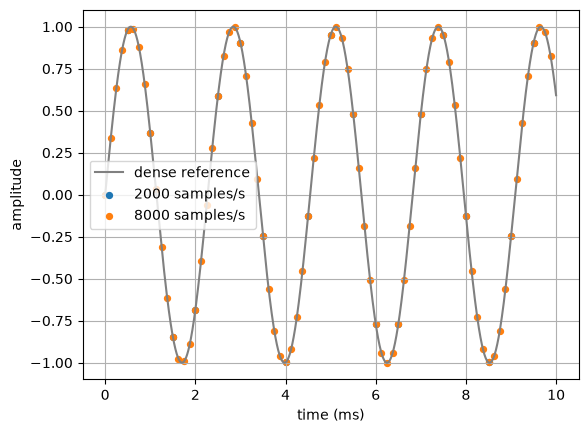

In [2]:
import numpy as np
import matplotlib.pyplot as plt

dense_t = np.linspace(0, 0.01, 5000, endpoint=False)
dense_x = np.sin(2*np.pi*440*dense_t)
plt.plot(dense_t*1000, dense_x, color="gray", label="dense reference")
for sr in [2000, 8000]:
    t = np.arange(sample_count(0.01, sr)) / sr
    x = np.sin(2*np.pi*440*t)
    plt.scatter(t*1000, x, s=18, label=f"{sr} samples/s")
plt.xlabel("time (ms)"); plt.ylabel("amplitude"); plt.legend(); plt.grid(True); plt.show()


## 3. 量化把连续幅度映射到有限等级

位深越低，等级越少，量化误差通常越明显。真实 PCM 常见 16 bit。


In [3]:
def quantize_unit(signal: np.ndarray, bits: int) -> np.ndarray:
    if bits < 2:
        raise ValueError("bits must be at least 2")
    levels = 2 ** bits
    clipped = np.clip(signal, -1.0, 1.0)
    return np.round((clipped + 1) * (levels - 1) / 2) * 2 / (levels - 1) - 1


x = np.linspace(-1, 1, 17)
for bits in [2, 3, 8]:
    q = quantize_unit(x, bits)
    print(bits, "bit -> unique levels used:", len(np.unique(q)), "max error:", np.max(np.abs(x-q)))


2 bit -> unique levels used: 4 max error: 0.33333333333333326
3 bit -> unique levels used: 8 max error: 0.1428571428571428
8 bit -> unique levels used: 17 max error: 0.0039215686274509665


## 4. PCM、dtype 与通道共同构成输入契约

单声道常见 shape `[T]`，双声道常见 `[T,2]`。不能在不知道通道含义时随意 `flatten()`。


In [4]:
mono = np.array([0.0, 0.5, -0.5, 0.999], dtype=np.float32)
pcm16 = np.round(np.clip(mono, -1, 1) * 32767).astype(np.int16)
restored = pcm16.astype(np.float32) / 32767
stereo = np.stack([mono, 0.5 * mono], axis=1)

print("mono:", mono.shape, mono.dtype)
print("pcm16:", pcm16.shape, pcm16.dtype, pcm16)
print("stereo:", stereo.shape, stereo.dtype)
print("round-trip max error:", np.max(np.abs(mono-restored)))
assert stereo.shape == (4, 2)


mono: (4,) float32
pcm16: (4,) int16 [     0  16384 -16384  32734]
stereo: (4, 2) float32
round-trip max error: 1.5258789e-05


## 分层练习：不要一次做完

### A. 直觉与单位（每题 1 分）

1. 不看上文，用一句话定义：采样率。
2. 为 `量化` 写出单位；如果它没有单位，要明确说明。
3. 举一个生活中的例子解释 `位深`。
4. 画图说明 `通道` 增大时，横轴或纵轴怎样变化。

### B. 数字与预测（每题 2 分）

5. 自己构造一个包含具体数字的计算例子，并标出每一步单位。
6. 把本课一个参数改成 0.5 倍和 2 倍；运行前先画出预期图形。
7. 找出一个“代码能运行，但物理含义错误”的输入，解释为什么错误。
8. 用 `shape / dtype / min / max` 四项审计本课最重要的数组。

### C. 实现与迁移（每题 3 分）

9. 从空白实现：**实现 sample_count 与 quantize_unit，并审计 mono/stereo 的 shape**，不能复制上面的函数。
10. 为实现写正常、边界和错误输入三类测试。
11. 换一组参数或换一条音频，验证结论是否仍成立。
12. 用 90 秒向没学过编程的人解释本课，只允许使用两个术语，并必须包含一个数字例子。

满分 24 分。达到 19 分且第 9～10 题完成，才建议继续；15～18 分次日重做；低于 15 分先回到图和单位。


## 最小掌握门禁

- [ ] 我能把本课每个量说成“含义 + 单位 + 数组表示”。
- [ ] 我能在运行前预测参数变化的方向。
- [ ] 我能从空白完成核心实现并覆盖边界输入。
- [ ] 我能说出一个常见误解，以及用什么证据推翻它。
- [ ] 我已把错题写入根目录 `LEARNING_LOG.md`，并安排明天、7 天、30 天复习。

下一步：音频基础 5：叠加、谐波、噪声与 SNR。
